# Analysis Challenge EDA

## Load packages and data

In [ ]:
#! pip install datasets

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import sys
import time
import seaborn as sns
import random

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torchvision.utils import make_grid
from torch.utils.data import DataLoader
from collections import Counter
from PIL import Image

# Set some options for printing all the columns
np.set_printoptions(precision = 10, threshold = sys.maxsize)
np.set_printoptions(linewidth = np.inf)

pd.set_option('display.max_columns', None)
pd.set_option('display.expand_frame_repr', False)
pd.set_option('max_colwidth', None)

pd.options.display.float_format = '{:,.10f}'.format

In [ ]:

from datasets import load_dataset

ds = load_dataset("ethz/food101")

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Extracting data files:   0%|          | 0/2 [00:00<?, ?it/s]

Generating train split:   0%|          | 0/75750 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/25250 [00:00<?, ? examples/s]

NotImplementedError: Loading a dataset cached in a LocalFileSystem is not supported.

## EDA
#### Overview

In [ ]:
print(ds)

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 75750
    })
    validation: Dataset({
        features: ['image', 'label'],
        num_rows: 25250
    })
})


In [ ]:
train_ds = ds['train']
validation_ds = ds['validation']

In [ ]:
labels = train_ds['label']  # get list of all labels
missing_indices = [i for i, lbl in enumerate(labels) if lbl is None]
print(f"Missing labels at indices: {missing_indices}")
print(f"Number of missing labels: {len(missing_indices)}")

Missing labels at indices: []
Number of missing labels: 0


### Food labels

In [ ]:
num_labels = len(train_ds.features['label'].names)
print(f"Number of unique labels: {num_labels}")

Number of unique labels: 101


In [ ]:
label_names = train_ds.features['label'].names
label_counts = Counter(train_ds['label'])

label_counts_named = {label_names[i]: count for i, count in label_counts.items()}
label_counts_named = dict(sorted(label_counts_named.items(), key=lambda x: x[1], reverse=True))
label_counts_named

{'beignets': 750,
 'prime_rib': 750,
 'ramen': 750,
 'hamburger': 750,
 'bruschetta': 750,
 'chicken_wings': 750,
 'pork_chop': 750,
 'greek_salad': 750,
 'sashimi': 750,
 'risotto': 750,
 'pizza': 750,
 'eggs_benedict': 750,
 'guacamole': 750,
 'chocolate_cake': 750,
 'miso_soup': 750,
 'apple_pie': 750,
 'fried_calamari': 750,
 'fried_rice': 750,
 'panna_cotta': 750,
 'hummus': 750,
 'carrot_cake': 750,
 'beet_salad': 750,
 'garlic_bread': 750,
 'hot_dog': 750,
 'steak': 750,
 'tiramisu': 750,
 'fish_and_chips': 750,
 'caesar_salad': 750,
 'tuna_tartare': 750,
 'pancakes': 750,
 'chocolate_mousse': 750,
 'lasagna': 750,
 'pad_thai': 750,
 'cheesecake': 750,
 'baklava': 750,
 'ice_cream': 750,
 'red_velvet_cake': 750,
 'tacos': 750,
 'foie_gras': 750,
 'grilled_cheese_sandwich': 750,
 'frozen_yogurt': 750,
 'seaweed_salad': 750,
 'breakfast_burrito': 750,
 'crab_cakes': 750,
 'strawberry_shortcake': 750,
 'beef_tartare': 750,
 'mussels': 750,
 'dumplings': 750,
 'creme_brulee': 750,
 

### Analyzing the images
#### Visualizing

In [ ]:
#Check for missing or corrupted images
bad_indices = []
for i in range(len(train_ds)):
    try:
        train_ds[i]['image'].verify()  # PIL verify
    except:
        bad_indices.append(i)

print(f"Corrupt images indices: {bad_indices}")

/usr/local/lib/python3.11/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Corrupt images indices: [62336]


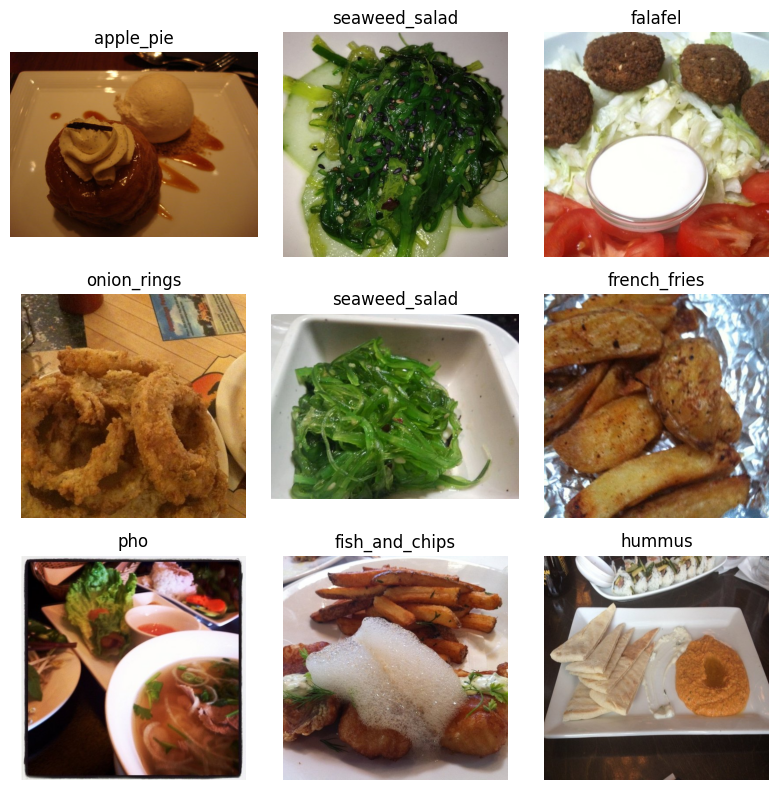

In [ ]:
# Randomly choose some images for preview
indices = random.sample(range(len(train_ds)), 9)
fig, axes = plt.subplots(3, 3, figsize=(8, 8))
for ax, idx in zip(axes.flatten(), indices):
    ex = ds["train"][idx]
    ax.imshow(ex["image"])
    ax.set_title(ds["train"].features["label"].names[ex["label"]])
    ax.axis("off")
plt.tight_layout()
plt.show()

#### Image sizes

In [ ]:
good_indices = [i for i in range(len(train_ds)) if i not in bad_indices]

image_sizes = []
width, height = [], []

for i in good_indices:
    image = train_ds[i]['image']
    w, h = image.size
    width.append(w)
    height.append(h)
    image_sizes.append((w, h))

image_sizes = np.array(image_sizes)
print(image_sizes.shape)

(75749, 2)


In [ ]:
# Smallest and largest sizes
print(width.min(axis=0))
print(`width.max(axis=0)`)
print(height.min(axis=0))
print(height.max(axis=0))

array([193, 122])

In [ ]:
image_sizes.min(axis=0)

array([193, 122])

The top 10 common image heights are: [(512, 56139), (384, 10977), (382, 1876), (341, 1129), (306, 787), (289, 680), (288, 678), (383, 340), (340, 296), (307, 286)]
The top 10 common image widths are: [(512, 66297), (384, 4866), (382, 2171), (511, 427), (306, 378), (289, 219), (341, 197), (288, 190), (383, 154), (307, 105)]
The top 10 common image sizes are: [((np.int64(512), np.int64(512)), 46687), ((np.int64(512), np.int64(384)), 10977), ((np.int64(384), np.int64(512)), 4866), ((np.int64(382), np.int64(512)), 2171), ((np.int64(512), np.int64(382)), 1876), ((np.int64(512), np.int64(341)), 1129), ((np.int64(512), np.int64(306)), 787), ((np.int64(512), np.int64(289)), 680), ((np.int64(512), np.int64(288)), 678), ((np.int64(511), np.int64(512)), 427)]


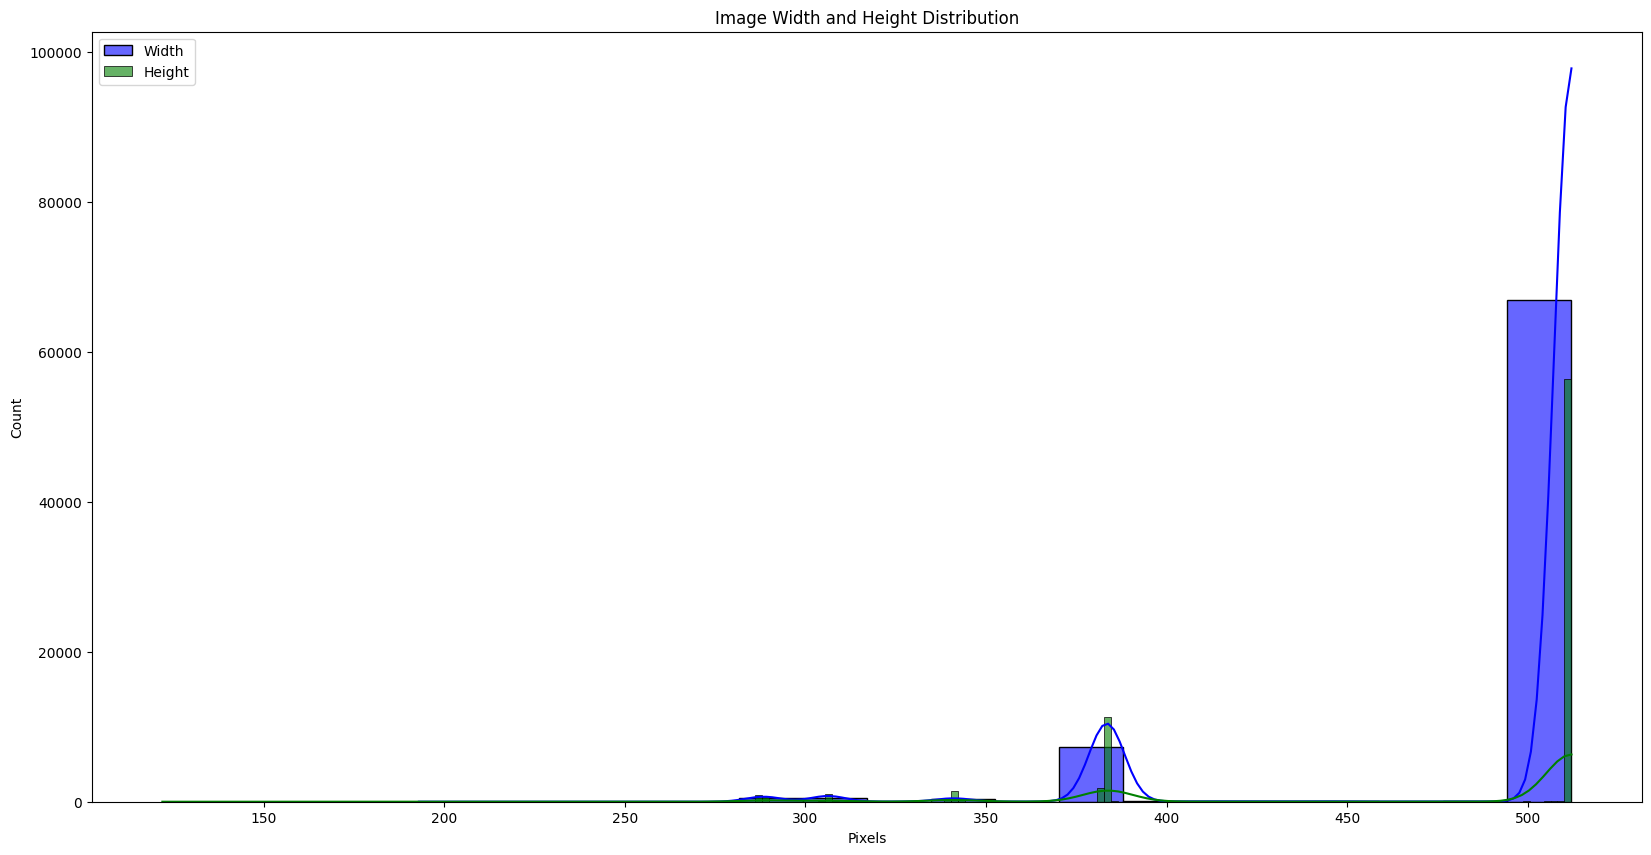

In [ ]:
height_count = Counter(height)
width_count = Counter(width)
# convert list-of-lists to list-of-tuples so Counter can hash them
size_tuples = [tuple(s) for s in image_sizes]
size_count = Counter(size_tuples)

print(f"The top 10 common image heights are: {height_count.most_common(10)}")
print(f"The top 10 common image widths are: {width_count.most_common(10)}")
print(f"The top 10 common image sizes are: {size_count.most_common(10)}")


# plot the distribution
plt.figure(figsize=(20, 10))
sns.histplot(width, color="blue", label="Width", kde=True, alpha=0.6)
sns.histplot(height, color="green", label="Height", kde=True, alpha=0.6)
plt.legend()
plt.title("Image Width and Height Distribution")
plt.xlabel("Pixels")
plt.show()
plt.close()

#### Pixel intensity

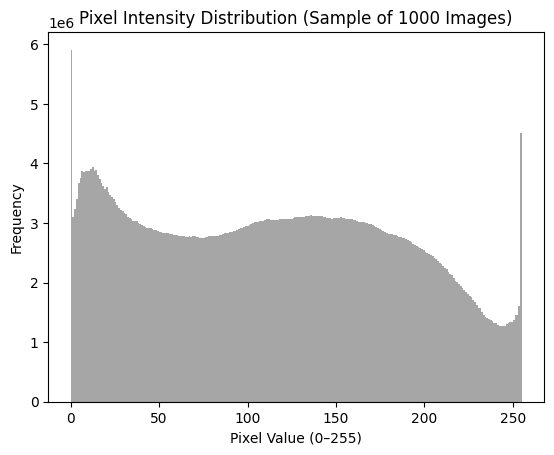

In [ ]:
subset = ds['train'].select(range(1000))  # Sample the first 1000 images
all_pixels = []

for example in subset:
    image_array = np.array(example['image'])  # shape: (H, W, 3)
    all_pixels.append(image_array.ravel())    # flatten to 1D

# Concatenate all pixel values into one big array
all_pixels_flat = np.concatenate(all_pixels)

# Plot the histogram
plt.hist(all_pixels_flat, bins=256, color='gray', alpha=0.7)
plt.title("Pixel Intensity Distribution (Sample of 1000 Images)")
plt.xlabel("Pixel Value (0–255)")
plt.ylabel("Frequency")
plt.show()